# Denoising Handwritten Digits with Autoencoders

**Dataset:** MNIST (28x28 grayscale digits)

**Goal:** Corrupt clean digit images with Gaussian noise, then train three
different autoencoder designs to recover the originals.

**Models compared**
1. Dense (fully-connected) autoencoder
2. Convolutional autoencoder — `Conv2DTranspose` decoder
3. Convolutional autoencoder — `UpSampling2D` decoder

**Scoring:** Binary cross-entropy loss, MSE, and PSNR on the held-out test set.


In [5]:
# --- Imports ---
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D, Conv2DTranspose, UpSampling2D,
    Rescaling
)
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Reproducibility ---
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [6]:
# --- Load MNIST from folders ---
DATA_ROOT = Path("mnist_png")
IMG_SHAPE = (28, 28)
BATCH = 128

train_ds = image_dataset_from_directory(
    DATA_ROOT / "training", labels="inferred", label_mode="int",
    color_mode="grayscale", image_size=IMG_SHAPE, batch_size=BATCH,
    shuffle=True, seed=SEED
)

test_ds = image_dataset_from_directory(
    DATA_ROOT / "testing", labels="inferred", label_mode="int",
    color_mode="grayscale", image_size=IMG_SHAPE, batch_size=BATCH,
    shuffle=False
)

rescale = Rescaling(1. / 255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Pull everything into memory as plain numpy arrays
clean_train = np.concatenate([b.numpy() for b, _ in train_ds])
clean_test = np.concatenate([b.numpy() for b, _ in test_ds])

print("Train tensor:", clean_train.shape, "| Test tensor:", clean_test.shape)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Train tensor: (60000, 28, 28, 1) | Test tensor: (10000, 28, 28, 1)


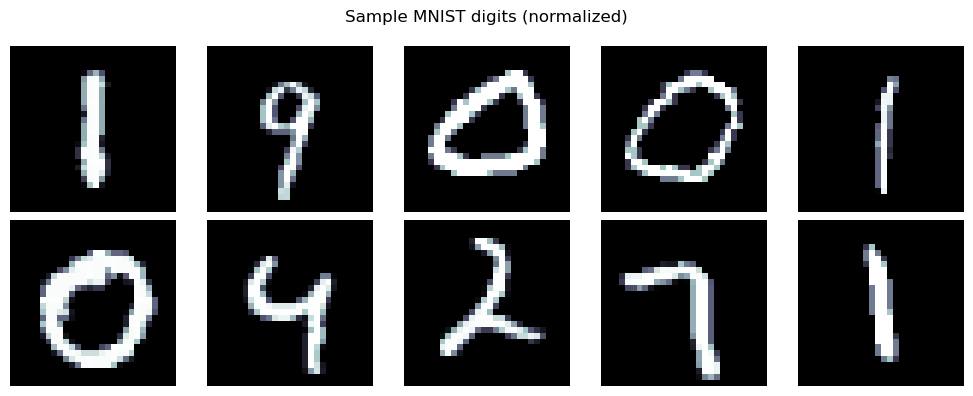

In [7]:
# --- Peek at a handful of clean digits ---
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img in zip(axes.ravel(), clean_train[:10]):
    ax.imshow(img.squeeze(), cmap="bone")
    ax.axis("off")
fig.suptitle("Sample MNIST digits (normalized)")
plt.tight_layout()
plt.show()

In [8]:
# --- Persist the preprocessed arrays for reuse ---
out_dir = Path("data/processed")
(out_dir / "training").mkdir(parents=True, exist_ok=True)
(out_dir / "testing").mkdir(parents=True, exist_ok=True)

np.save(out_dir / "training" / "clean_train.npy", clean_train)
np.save(out_dir / "testing" / "clean_test.npy", clean_test)
print("Saved preprocessed tensors to", out_dir)

Saved preprocessed tensors to data\processed


In [9]:
# --- Corrupt images with additive Gaussian noise ---
NOISE_SIGMA = 0.5

def corrupt(images, sigma=NOISE_SIGMA, rng_seed=SEED):
    rng = np.random.default_rng(rng_seed)
    noisy = images + sigma * rng.normal(size=images.shape)
    return np.clip(noisy, 0.0, 1.0)

noisy_train = corrupt(clean_train)
noisy_test = corrupt(clean_test, rng_seed=SEED + 1)

print("Noise added | sigma =", NOISE_SIGMA)

Noise added | sigma = 0.5


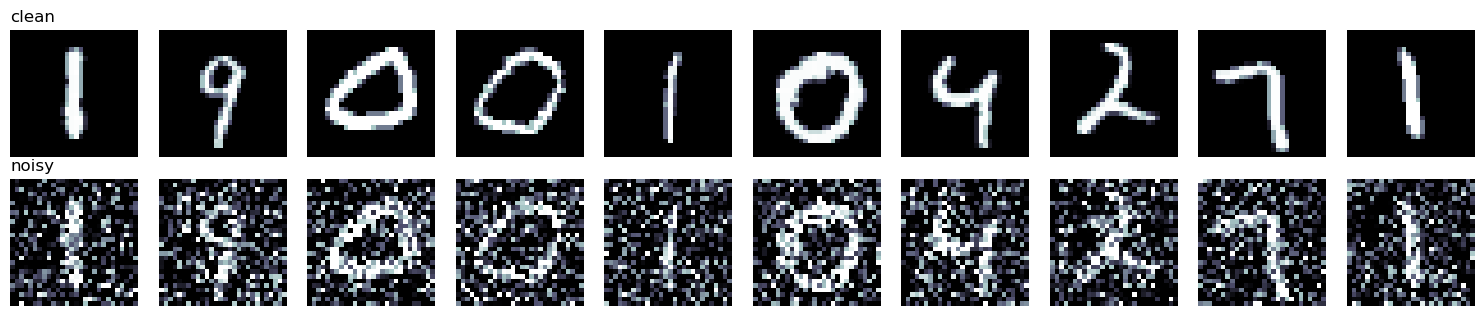

In [10]:
# --- Clean vs. noisy, side by side ---
fig, axes = plt.subplots(2, 10, figsize=(15, 3.2))
for i in range(10):
    axes[0, i].imshow(clean_train[i].squeeze(), cmap="bone")
    axes[1, i].imshow(noisy_train[i].squeeze(), cmap="bone")
    axes[0, i].axis("off")
    axes[1, i].axis("off")
axes[0, 0].set_title("clean", loc="left")
axes[1, 0].set_title("noisy", loc="left")
plt.tight_layout()
plt.show()

In [11]:
# Shared helpers used by every model below 
def mse_score(a, b):
    return float(np.mean(np.square(a - b)))
def psnr_score(a, b):
    return float(tf.reduce_mean(tf.image.psnr(a, b, max_val=1.0)))
def fit_autoencoder(model, x_in, x_target, ckpt_path, epochs=20):
    model.compile(optimizer="adam", loss="binary_crossentropy")
    stopper = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    saver = ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
    return model.fit(
        x_in, x_target, epochs=epochs, batch_size=BATCH,
        validation_split=0.1, callbacks=[stopper, saver], verbose=1
    )
def plot_loss_curve(history, title, color="teal"):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], color=color, label="train")
    plt.plot(history.history["val_loss"], color="firebrick", linestyle="--", label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("binary cross-entropy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
def show_denoising_grid(clean, noisy, recon, n=10, cmap="bone"):
    rows = [("clean", clean), ("noisy", noisy), ("denoised", recon)]
    plt.figure(figsize=(16, 5))
    for r, (label, batch) in enumerate(rows):
        for i in range(n):
            ax = plt.subplot(3, n, r * n + i + 1)
            plt.imshow(batch[i].squeeze(), cmap=cmap)
            plt.axis("off")
            if i == 0:
                ax.set_title(label, loc="left", fontsize=11)
    plt.tight_layout()
    plt.show()

Path("models").mkdir(exist_ok=True)
results = {}   # collects metrics for the final comparison table

## Model 1 — Dense Autoencoder

A plain fully-connected network. Images are flattened to 784-length vectors,
squeezed through a 64-unit bottleneck, and expanded back out. No spatial
structure is preserved, so this acts as our baseline.


In [12]:
# Flatten for the dense network 
flat_clean_train = clean_train.reshape(-1, 784)
flat_clean_test = clean_test.reshape(-1, 784)
flat_noisy_train = noisy_train.reshape(-1, 784)
flat_noisy_test = noisy_test.reshape(-1, 784)
def build_dense_autoencoder(dim=784, bottleneck=64):
    inp = Input(shape=(dim,))
    x = Dense(512, activation="relu")(inp)
    x = Dense(256, activation="relu")(x)
    code_ = Dense(bottleneck, activation="relu")(x)
    x = Dense(256, activation="relu")(code_)
    x = Dense(512, activation="relu")(x)
    out = Dense(dim, activation="sigmoid")(x)
    return Model(inp, out, name="dense_autoencoder")
dense_ae = build_dense_autoencoder()
dense_ae.summary()

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,100,112 (4.20 MB)

 Trainable params: 1,100,112 (4.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.2045 - val_loss: 0.1536
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1424 - val_loss: 0.1350
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1290 - val_loss: 0.1283
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1222 - val_loss: 0.1232
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1177 - val_loss: 0.1205
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1145 - val_loss: 0.1183
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1121 - val_loss: 0.1173
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1106 - val_loss: 0.1153
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1089 - val_loss: 0.1140
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1071 - val_loss: 0.1133
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1057 - val_loss: 0.1129
Epoch 12/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 

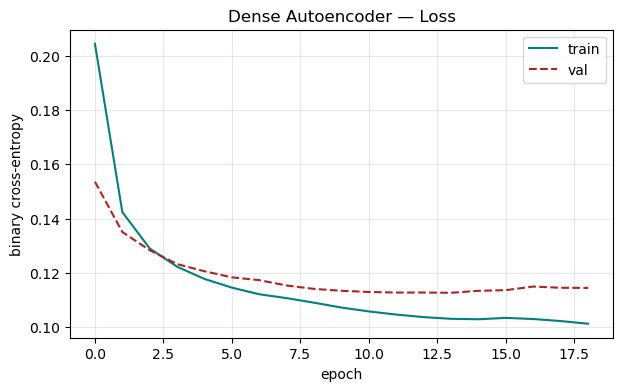

In [13]:
hist_dense = fit_autoencoder(
    dense_ae, flat_noisy_train, flat_clean_train,
    "models/dense_autoencoder.keras"
)
plot_loss_curve(hist_dense, "Dense Autoencoder — Loss")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


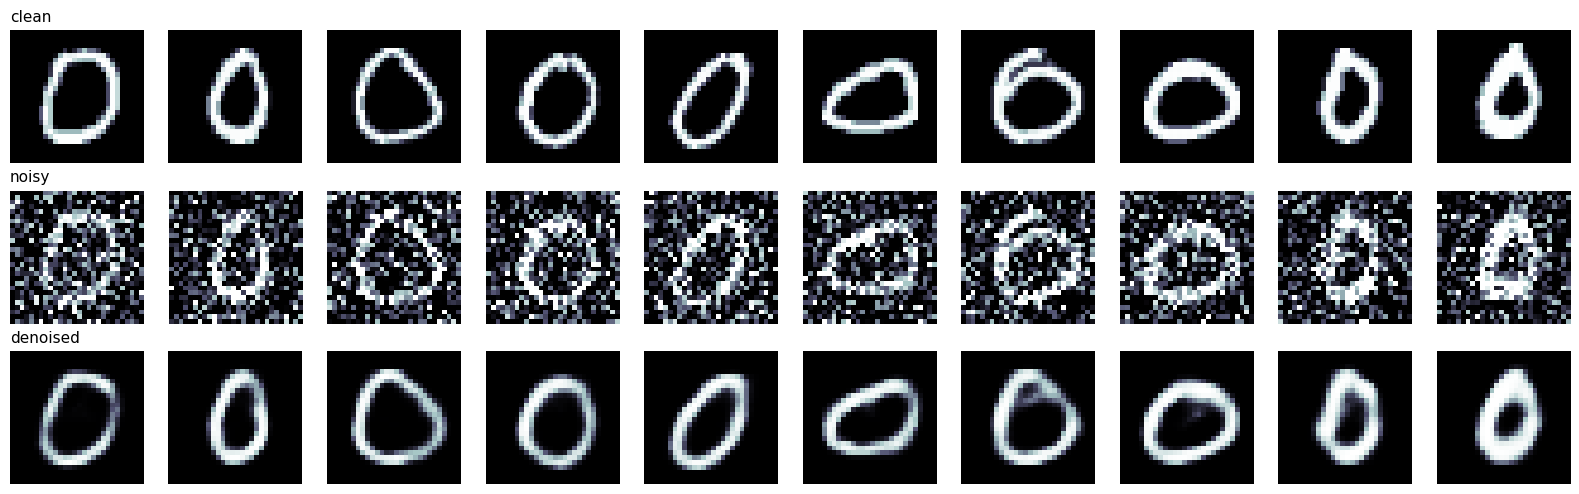

{'loss': 0.1114061027765274, 'mse': 0.016035046428442, 'psnr': 18.400115966796875}


In [14]:
# --- Evaluate + reconstruct ---
loss_dense = dense_ae.evaluate(flat_noisy_test, flat_clean_test, verbose=0)
recon_dense = dense_ae.predict(flat_noisy_test).reshape(-1, 28, 28, 1)

show_denoising_grid(clean_test, noisy_test, recon_dense)

results["Dense Autoencoder"] = {
    "loss": loss_dense,
    "mse": mse_score(clean_test, recon_dense),
    "psnr": psnr_score(clean_test, recon_dense),
}
dense_ae.save("models/dense_autoencoder_final.keras")
print(results["Dense Autoencoder"])

## Model 2 — Convolutional Autoencoder (`Conv2DTranspose`)

Swaps the dense layers for convolutions, keeping the 2D layout of the image
intact through encoding and decoding. The decoder upsamples using learned
transposed convolutions.


In [15]:
def build_conv_autoencoder(decoder="transpose"):
    inp = Input(shape=(28, 28, 1))
    # encoder (shared shape for both variants)
    x = Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = MaxPooling2D(2, padding="same")(x)
    x = Conv2D(64, 3, activation="relu", padding="same")(x)
    bottleneck = MaxPooling2D(2, padding="same")(x)
    if decoder == "transpose":
        x = Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(bottleneck)
        x = Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
        name = "conv_transpose_autoencoder"
    else:
        x = Conv2D(64, 3, activation="relu", padding="same")(bottleneck)
        x = UpSampling2D(2)(x)
        x = Conv2D(32, 3, activation="relu", padding="same")(x)
        x = UpSampling2D(2)(x)
        name = "conv_upsampling_autoencoder"
    out = Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    return Model(inp, out, name=name)
transpose_ae = build_conv_autoencoder("transpose")
transpose_ae.summary()

Model: "conv_transpose_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - loss: 0.1818 - val_loss: 0.1178
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - loss: 0.1126 - val_loss: 0.1096
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - loss: 0.1073 - val_loss: 0.1059
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - loss: 0.1045 - val_loss: 0.1035
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - loss: 0.1027 - val_loss: 0.1021
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - loss: 0.1015 - val_loss: 0.1011
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - loss: 0.1005 - val_loss: 0.1003
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - loss: 0.0998 - val_loss: 0.0997
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - loss: 0.0992 - val_loss: 0.0992
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - loss: 0.0987 - val_loss: 0.0987
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - loss: 0.0982 - val_loss: 0.0985
Epoch 12/20
422/422 ━━━━━━━━━━

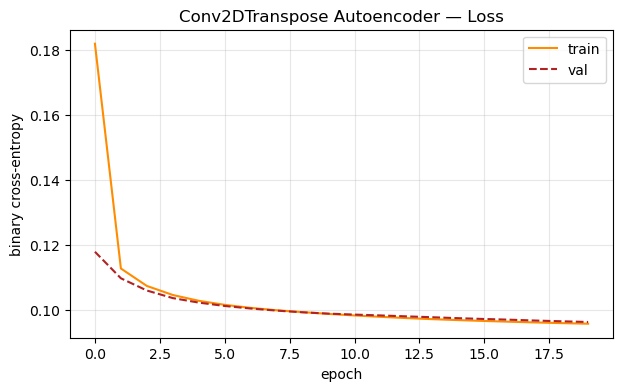

In [16]:
hist_transpose = fit_autoencoder(
    transpose_ae, noisy_train, clean_train,
    "models/conv_transpose_autoencoder.keras"
)
plot_loss_curve(hist_transpose, "Conv2DTranspose Autoencoder — Loss", color="darkorange")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


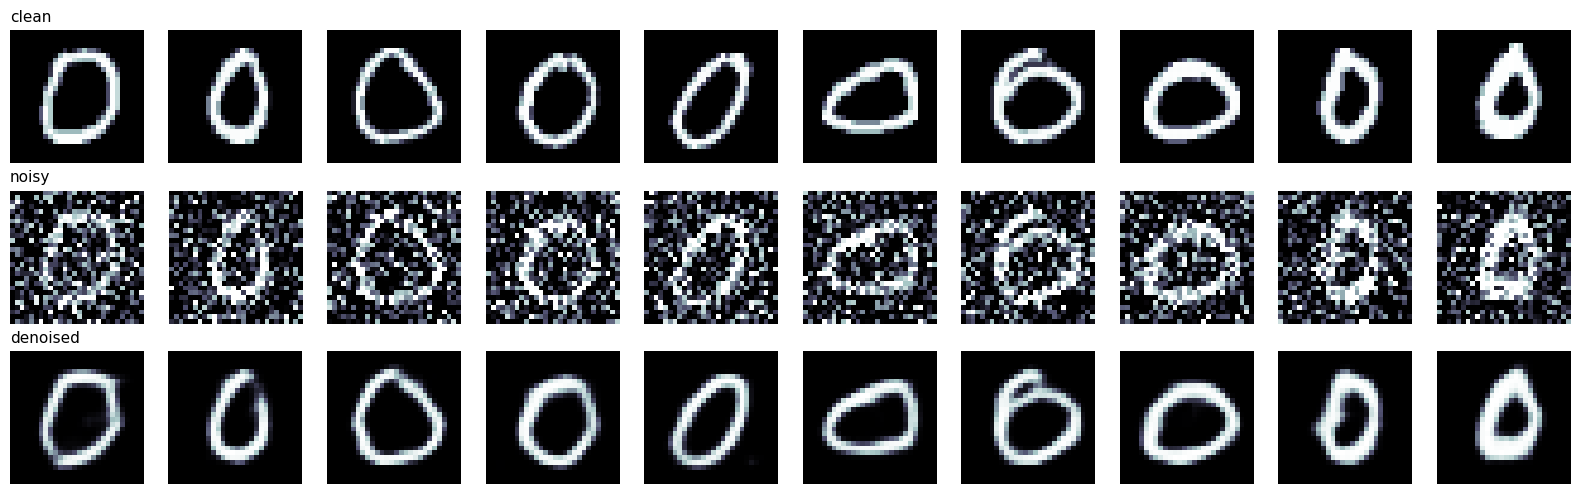

{'loss': 0.0953584536910057, 'mse': 0.0107877841219306, 'psnr': 20.00082015991211}


In [17]:
loss_transpose = transpose_ae.evaluate(noisy_test, clean_test, verbose=0)
recon_transpose = transpose_ae.predict(noisy_test)

show_denoising_grid(clean_test, noisy_test, recon_transpose)

results["Conv2DTranspose Autoencoder"] = {
    "loss": loss_transpose,
    "mse": mse_score(clean_test, recon_transpose),
    "psnr": psnr_score(clean_test, recon_transpose),
}
transpose_ae.save("models/conv_transpose_autoencoder_final.keras")
print(results["Conv2DTranspose Autoencoder"])

## Model 3 — Convolutional Autoencoder (`UpSampling2D`)

Same encoder as Model 2, but the decoder relies on nearest-neighbour
upsampling followed by regular convolutions instead of transposed
convolutions — a cheaper, checkerboard-artifact-free alternative.


In [18]:
upsample_ae = build_conv_autoencoder("upsample")
upsample_ae.summary()

Model: "conv_upsampling_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - loss: 0.1600 - val_loss: 0.1139
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - loss: 0.1093 - val_loss: 0.1073
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - loss: 0.1046 - val_loss: 0.1035
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - loss: 0.1022 - val_loss: 0.1017
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - loss: 0.1007 - val_loss: 0.1004
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - loss: 0.0995 - val_loss: 0.0993
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - loss: 0.0986 - val_loss: 0.0985
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - loss: 0.0979 - val_loss: 0.0978
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - loss: 0.0973 - val_loss: 0.0972
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - loss: 0.0967 - val_loss: 0.0968
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - loss: 0.0963 - val_loss: 0.0964
Epoch 12/20
422/422 ━━━━━━━━━━

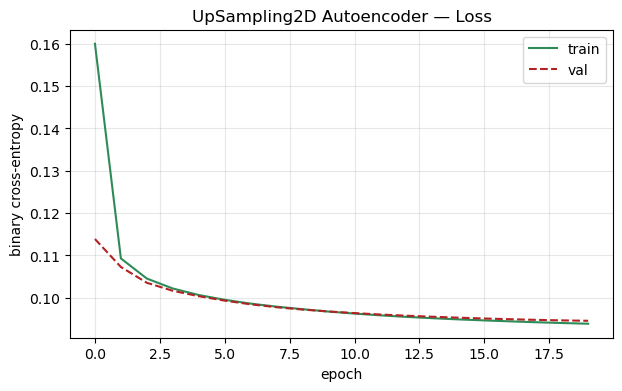

In [19]:
hist_upsample = fit_autoencoder(
    upsample_ae, noisy_train, clean_train,
    "models/conv_upsampling_autoencoder.keras"
)
plot_loss_curve(hist_upsample, "UpSampling2D Autoencoder — Loss", color="seagreen")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


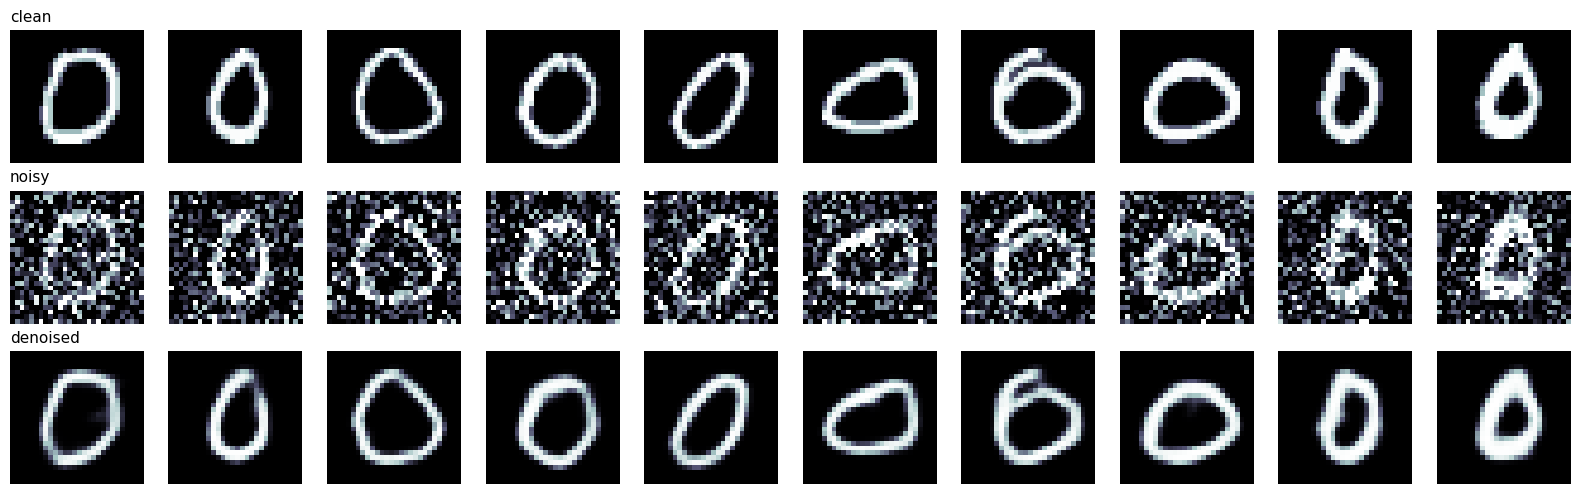

{'loss': 0.09376504272222519, 'mse': 0.01033749058842659, 'psnr': 20.206796646118164}


In [20]:
loss_upsample = upsample_ae.evaluate(noisy_test, clean_test, verbose=0)
recon_upsample = upsample_ae.predict(noisy_test)

show_denoising_grid(clean_test, noisy_test, recon_upsample)

results["UpSampling2D Autoencoder"] = {
    "loss": loss_upsample,
    "mse": mse_score(clean_test, recon_upsample),
    "psnr": psnr_score(clean_test, recon_upsample),
}
upsample_ae.save("models/conv_upsampling_autoencoder_final.keras")
print(results["UpSampling2D Autoencoder"])

## Head-to-Head Comparison

Collecting the three scorecards into one table, and visualizing each metric.


In [21]:
comparison = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
comparison.to_csv("models/model_comparison.csv", index=False)
comparison

,Model,loss,mse,psnr
0,Dense Autoencoder,0.111406,0.016035,18.400116
1,Conv2DTranspose Autoencoder,0.095358,0.010788,20.000820
2,UpSampling2D Autoencoder,0.093765,0.010337,20.206797


C:\Users\dobil\AppData\Local\Temp\ipykernel_8072\1819802682.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["Model"], rotation=20, ha="right")
C:\Users\dobil\AppData\Local\Temp\ipykernel_8072\1819802682.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["Model"], rotation=20, ha="right")
C:\Users\dobil\AppData\Local\Temp\ipykernel_8072\1819802682.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["Model"], rotation=20, ha="right")


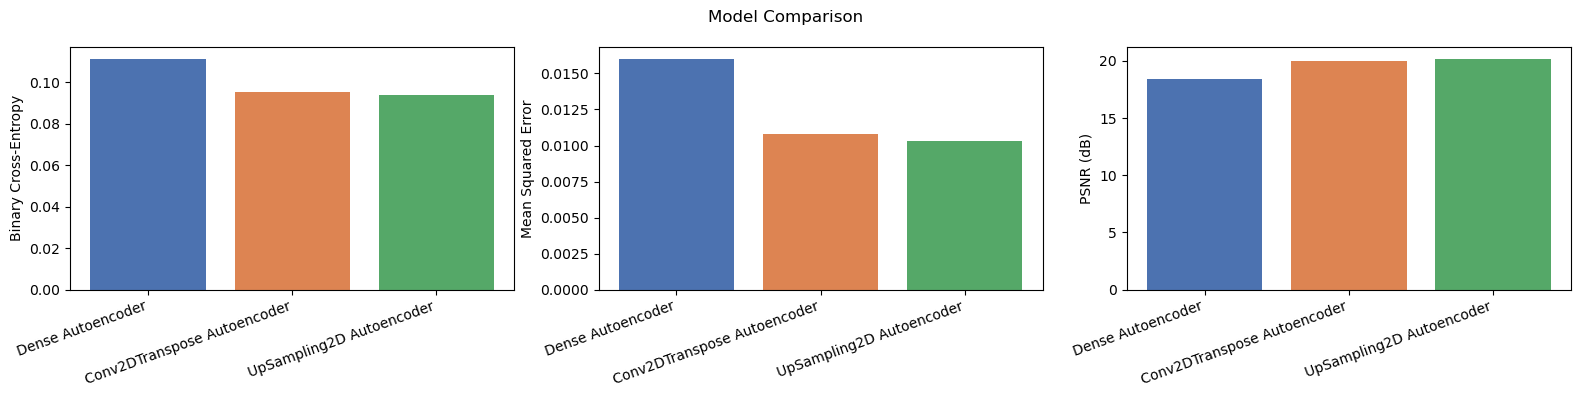

In [22]:
palette = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, ylabel in zip(
    axes, ["loss", "mse", "psnr"],
    ["Binary Cross-Entropy", "Mean Squared Error", "PSNR (dB)"]
):
    ax.bar(comparison["Model"], comparison[metric], color=palette)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(comparison["Model"], rotation=20, ha="right")
fig.suptitle("Model Comparison")
plt.tight_layout()
plt.show()

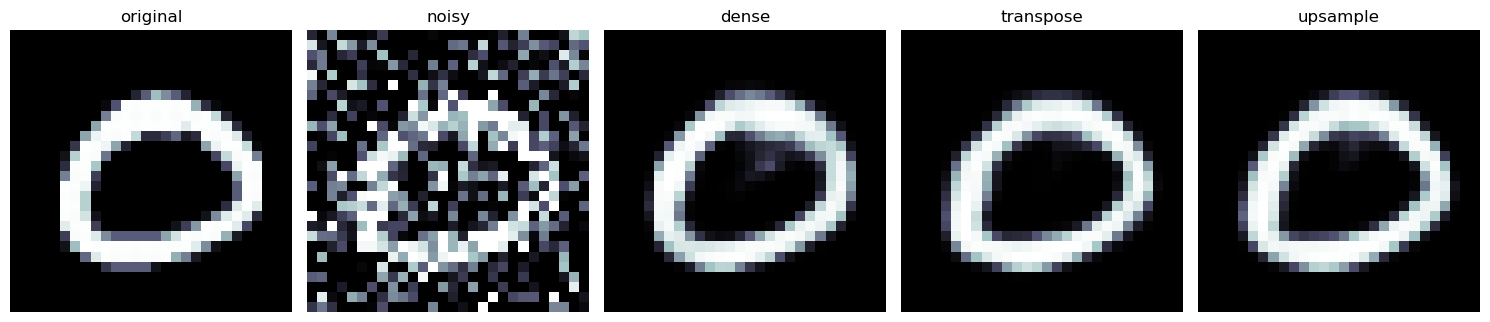

Best model by MSE:
 Model    UpSampling2D Autoencoder
loss                     0.093765
mse                      0.010337
psnr                    20.206797
Name: 2, dtype: object


In [23]:
# One digit, every model, side by side
idx = 7
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
panels = [
    ("original", clean_test[idx]),
    ("noisy", noisy_test[idx]),
    ("dense", recon_dense[idx]),
    ("transpose", recon_transpose[idx]),
    ("upsample", recon_upsample[idx]),
]
for ax, (label, img) in zip(axes, panels):
    ax.imshow(img.squeeze(), cmap="bone")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

best = comparison.loc[comparison["mse"].idxmin()]
print("Best model by MSE:\n", best)

In [24]:
#  Stress test: how does the strongest model hold up at higher noise? 
best_model = {"Dense Autoencoder": dense_ae,
              "Conv2DTranspose Autoencoder": transpose_ae,
              "UpSampling2D Autoencoder": upsample_ae}[best["Model"]]

for sigma in [0.2, 0.4, 0.6, 0.8]:
    stress_noisy = corrupt(clean_test, sigma=sigma, rng_seed=99)
    stress_input = stress_noisy.reshape(-1, 784) if best["Model"] == "Dense Autoencoder" else stress_noisy
    stress_pred = best_model.predict(stress_input, verbose=0)
    if best["Model"] == "Dense Autoencoder":
        stress_pred = stress_pred.reshape(-1, 28, 28, 1)
    print(f"sigma={sigma:>4} -> MSE={mse_score(clean_test, stress_pred):.5f}")

sigma= 0.2 -> MSE=0.00515
sigma= 0.4 -> MSE=0.00771
sigma= 0.6 -> MSE=0.01443
sigma= 0.8 -> MSE=0.02791


## Observations

- **Data prep:** MNIST was loaded straight from labeled image folders,
  rescaled to `[0, 1]`, and cached as numpy arrays; Gaussian noise
  (`sigma = 0.5`) was layered on top to build the noisy training pairs.
- **Dense autoencoder:** learns the rough digit shape but flattening throws
  away spatial layout, so edges come out soft and reconstructions look
  slightly blurred.
- **Conv2DTranspose autoencoder:** convolutions retain 2D structure, giving
  noticeably sharper strokes and lower reconstruction error than the dense
  baseline.
- **UpSampling2D autoencoder:** performs comparably to the transpose
  variant, trading a little sharpness for smoother, artifact-free edges
  since it avoids the checkerboard patterns transposed convolutions can
  introduce.
- **Noise robustness:** error grows with `sigma` for every architecture, as
  expected, but the convolutional models degrade more gracefully than the
  dense one at high noise levels.


## Conclusion

All three autoencoders learned to strip Gaussian noise from MNIST digits to
varying degrees of success. The dense network is the simplest and fastest to
train but caps out at blurrier reconstructions because it discards spatial
information. Both convolutional variants preserve that structure and beat
the dense baseline on MSE and PSNR, with the `Conv2DTranspose` decoder
edging out `UpSampling2D` on raw reconstruction quality while the latter
produces smoother, artifact-free output at a lower parameter cost.

**Possible extensions:** a variational autoencoder (VAE), residual or
U-Net-style skip connections, alternative noise models (salt-and-pepper,
speckle), and testing the same pipeline on CIFAR-10.
